# Movie Recommendation System using MovieLens 20M
### Methods Implemented
1. Popularity-Based
2. Content-Based (TF-IDF + TruncatedSVD)
3. Collaborative Filtering
4. Matrix Factorization (Surprise SVD)
5. Hybrid Recommendation



In [1]:

!pip install pandas numpy matplotlib scikit-learn scipy scikit-surprise tf

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

from surprise import Dataset,Reader,SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

plt.rcParams["figure.figsize"]=(8,5)


## Load Dataset

In [3]:
movies=pd.read_csv("movies.csv")
ratings=pd.read_csv("ratings.csv")
tags=pd.read_csv("tags.csv")

display(movies.head())
display(ratings.head())
display(tags.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,1240597180
1,65,208,dark hero,1368150078
2,65,353,dark hero,1368150079
3,65,521,noir thriller,1368149983
4,65,592,dark hero,1368150078


## Dataset Overview

In [4]:
print("Movies:",movies.shape)
print("Ratings:",ratings.shape)
print("Tags:",tags.shape)

summary=pd.DataFrame({
'Dataset':['Movies','Ratings','Tags'],
'Rows':[len(movies),len(ratings),len(tags)],
'Columns':[movies.shape[1],ratings.shape[1],tags.shape[1]]
})
display(summary)


Movies: (27278, 3)
Ratings: (1726127, 4)
Tags: (465564, 4)


,Dataset,Rows,Columns
0,Movies,27278,3
1,Ratings,1726127,4
2,Tags,465564,4


## Visualization: Rating Distribution

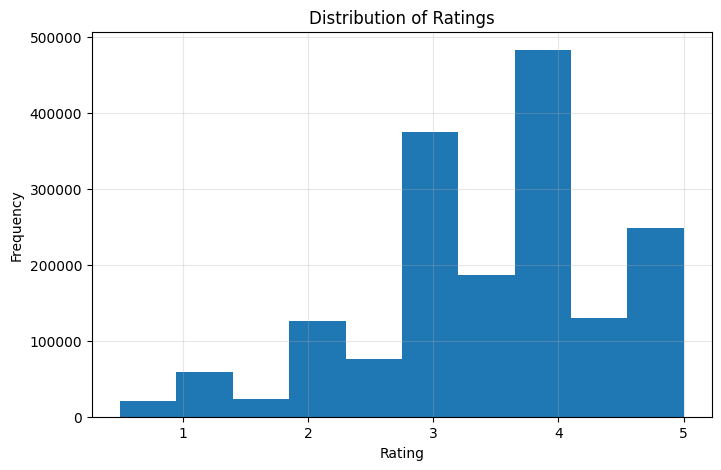

In [5]:
plt.figure()
ratings['rating'].hist(bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.grid(alpha=.3)
plt.show()


## Preprocessing

In [6]:
tags=tags.dropna(subset=['tag'])
tags['tag']=tags['tag'].str.lower()

movie_tags=tags.groupby('movieId')['tag'].apply(lambda x:' '.join(x)).reset_index()
movies_metadata=movies.merge(movie_tags,on='movieId',how='left')
movies_metadata['tag']=movies_metadata['tag'].fillna('')
movies_metadata['metadata']=movies_metadata['genres']+' '+movies_metadata['tag']

display(movies_metadata.head())


,movieId,title,genres,tag,metadata
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,watched computer animation disney animated fea...,Adventure|Animation|Children|Comedy|Fantasy wa...
1,2,Jumanji (1995),Adventure|Children|Fantasy,time travel adapted from:book board game child...,Adventure|Children|Fantasy time travel adapted...
2,3,Grumpier Old Men (1995),Comedy|Romance,old people that is actually funny sequel fever...,Comedy|Romance old people that is actually fun...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,chick flick revenge characters chick flick cha...,Comedy|Drama|Romance chick flick revenge chara...
4,5,Father of the Bride Part II (1995),Comedy,diane keaton family sequel steve martin weddin...,Comedy diane keaton family sequel steve martin...


## Popularity Recommendation

In [7]:
movie_stats=ratings.groupby('movieId').agg(avg_rating=('rating','mean'),
rating_count=('rating','count')).reset_index()

popular=movie_stats.merge(movies,on='movieId')
popular=popular[popular.rating_count>100]
popular=popular.sort_values('avg_rating',ascending=False)

display(popular[['title','avg_rating','rating_count']].head(10))


,title,avg_rating,rating_count
314,"Shawshank Redemption, The (1994)",4.458019,5300
835,"Godfather, The (1972)",4.380028,3530
49,"Usual Suspects, The (1995)",4.362889,4015
7226,Band of Brothers (2001),4.324934,377
521,Schindler's List (1993),4.310846,4269
887,Casablanca (1942),4.284295,2114
1185,"Godfather: Part II, The (1974)",4.284260,2357
3299,Creature Comforts (1989),4.258140,215
879,Rear Window (1954),4.251835,1499
925,"Thin Man, The (1934)",4.245253,316


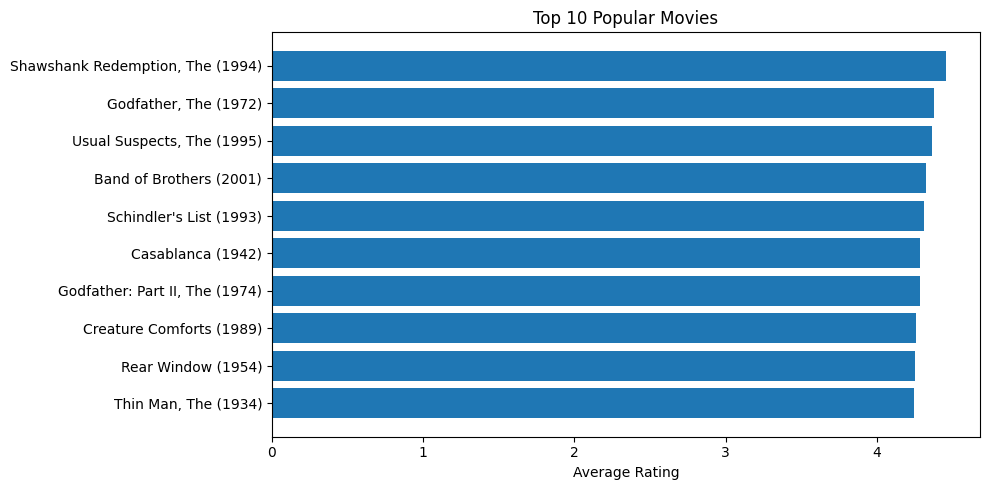

POPULARITY-BASED RECOMMENDATIONS


,movieId,avg_rating,rating_count,title,genres
314,318,4.458019,5300,"Shawshank Redemption, The (1994)",Crime|Drama
835,858,4.380028,3530,"Godfather, The (1972)",Crime|Drama
49,50,4.362889,4015,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
7226,7502,4.324934,377,Band of Brothers (2001),Action|Drama|War
521,527,4.310846,4269,Schindler's List (1993),Drama|War
887,912,4.284295,2114,Casablanca (1942),Drama|Romance
1185,1221,4.284260,2357,"Godfather: Part II, The (1974)",Crime|Drama
3299,3429,4.258140,215,Creature Comforts (1989),Animation|Comedy
879,904,4.251835,1499,Rear Window (1954),Mystery|Thriller
925,950,4.245253,316,"Thin Man, The (1934)",Comedy|Crime


In [11]:
top10=popular.head(10)
plt.figure(figsize=(10,5))
plt.barh(top10['title'][::-1],top10['avg_rating'][::-1])
plt.title("Top 10 Popular Movies")
plt.xlabel("Average Rating")
plt.tight_layout()
plt.show()
print("="*70)
print("POPULARITY-BASED RECOMMENDATIONS")
print("="*70)
display(top10)

## Content-Based Filtering

In [12]:
tfidf=TfidfVectorizer(stop_words='english')
tfidf_matrix=tfidf.fit_transform(movies_metadata['metadata'])

svd_content=TruncatedSVD(n_components=100,random_state=42)
latent_matrix_1=svd_content.fit_transform(tfidf_matrix)

content_similarity=cosine_similarity(latent_matrix_1)

indices=pd.Series(movies_metadata.index,index=movies_metadata.title).drop_duplicates()

def content_recommend(title,n=10):
    idx=indices[title]
    scores=list(enumerate(content_similarity[idx]))
    scores=sorted(scores,key=lambda x:x[1],reverse=True)[1:n+1]
    ids=[i[0] for i in scores]
    return movies_metadata.iloc[ids][['title','genres']]

# content_recommend('Toy Story (1995)')
print("="*70)
print("CONTENT-BASED RECOMMENDATIONS")
print("="*70)

movie_name="Toy Story (1995)"
print(f"Movies similar to: {movie_name}")
display(content_recommend(movie_name,10))



CONTENT-BASED RECOMMENDATIONS
Movies similar to: Toy Story (1995)


,title,genres
3027,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
11614,Ratatouille (2007),Animation|Children|Drama
5121,Ice Age (2002),Adventure|Animation|Children|Comedy
2270,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy
6271,Finding Nemo (2003),Adventure|Animation|Children|Comedy
4790,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
23636,Planes: Fire & Rescue (2014),Adventure|Animation|Comedy
21168,Monsters University (2013),Adventure|Animation|Comedy
13767,Up (2009),Adventure|Animation|Children|Drama
15401,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX


## Collaborative Filtering

In [13]:
user_movie=ratings.pivot_table(index='userId',columns='movieId',values='rating').fillna(0)
user_sparse=csr_matrix(user_movie.values)

svd_cf=TruncatedSVD(n_components=100,random_state=42)
latent_matrix_2=svd_cf.fit_transform(user_sparse)

user_similarity=cosine_similarity(latent_matrix_2)

print(latent_matrix_2.shape)
print("="*70)
print("COLLABORATIVE FILTERING - SIMILAR USERS")
print("="*70)

user_id=1
similar_users=np.argsort(user_similarity[user_id-1])[::-1][1:11]

similar_df=pd.DataFrame({
    "Rank":range(1,11),
    "Similar User ID":similar_users+1,
    "Similarity Score":user_similarity[user_id-1][similar_users]
})

display(similar_df)


(11678, 100)
COLLABORATIVE FILTERING - SIMILAR USERS


,Rank,Similar User ID,Similarity Score
0,1,5366,0.759496
1,2,2595,0.733331
2,3,7412,0.728493
3,4,1716,0.726662
4,5,1081,0.716164
5,6,8508,0.715730
6,7,8056,0.711851
7,8,147,0.699422
8,9,9654,0.696168
9,10,9369,0.692735


## Matrix Factorization (Surprise SVD)

In [14]:
reader=Reader(rating_scale=(0.5,5))
data=Dataset.load_from_df(ratings[['userId','movieId','rating']],reader)

trainset,testset=train_test_split(data,test_size=0.2,random_state=42)

algo=SVD()
algo.fit(trainset)

pred=algo.test(testset)
rmse=accuracy.rmse(pred)
print("RMSE:",rmse)


RMSE: 0.8235
RMSE: 0.8235406932675519


In [15]:
def recommend_svd(user_id,n=10):
    watched=ratings.loc[ratings.userId==user_id,'movieId'].values
    rec=[]
    for m in ratings.movieId.unique():
        if m not in watched:
            rec.append((m,algo.predict(user_id,m).est))
    rec=sorted(rec,key=lambda x:x[1],reverse=True)[:n]
    return pd.DataFrame(
        [[movies.loc[movies.movieId==m,'title'].values[0],s] for m,s in rec],
        columns=['Movie','Predicted Rating']
    )
    print("="*70)
print("MATRIX FACTORIZATION (SURPRISE SVD)")
print("="*70)

svd_rec=recommend_svd(1,10)
svd_rec.index=np.arange(1,len(svd_rec)+1)
svd_rec.index.name="Rank"

display(svd_rec)


MATRIX FACTORIZATION (SURPRISE SVD)


,Movie,Predicted Rating
Rank,,
1,Day for Night (La Nuit Américaine) (1973),4.743628
2,"Short Film About Killing, A (Krótki film o zab...",4.569247
3,"Dark Knight Rises, The (2012)",4.525987
4,"Wedding Banquet, The (Xi yan) (1993)",4.497325
5,"Lady Eve, The (1941)",4.475390
6,Black Mirror (2011),4.470788
7,"Power of Nightmares, The: The Rise of the Poli...",4.468430
8,"Decalogue, The (Dekalog) (1989)",4.466771
9,Shenandoah (1965),4.463355


## Hybrid Recommendation

In [16]:
def hybrid_recommend(title,user_id,n=10):
    idx=indices[title]
    watched=set(ratings.loc[ratings.userId==user_id,'movieId'])
    rows=[]
    for i,row in movies_metadata.iterrows():
        if row.movieId in watched:
            continue
        cscore=content_similarity[idx][i]
        pscore=algo.predict(user_id,row.movieId).est/5
        pop=movie_stats.loc[movie_stats.movieId==row.movieId,'avg_rating']
        popscore=0 if len(pop)==0 else pop.values[0]/5
        final=0.4*cscore+0.4*pscore+0.2*popscore
        rows.append((row.title,final))
    return pd.DataFrame(sorted(rows,key=lambda x:x[1],reverse=True)[:n],
                        columns=['Movie','Hybrid Score'])

# hybrid_recommend('Toy Story (1995)',1)
print("="*70)
print("HYBRID RECOMMENDATIONS")
print("="*70)

hybrid=hybrid_recommend("Toy Story (1995)",1,10)
hybrid.index=np.arange(1,len(hybrid)+1)
hybrid.index.name="Rank"

display(hybrid)


HYBRID RECOMMENDATIONS


,Movie,Hybrid Score
Rank,,
1,Toy Story (1995),0.862032
2,Ratatouille (2007),0.859726
3,Finding Nemo (2003),0.843150
4,Toy Story 2 (1999),0.833220
5,Ice Age (2002),0.829855
6,Up (2009),0.827172
7,"Monsters, Inc. (2001)",0.824373
8,Toy Story 3 (2010),0.815450
9,Wallace & Gromit: The Wrong Trousers (1993),0.811076


## Conclusion
The hybrid model combines popularity, metadata similarity, and collaborative learning to generate more robust recommendations than any individual approach.

In [20]:
print("="*70)
print("COMPARISON OF RECOMMENDERS")
print("="*70)

print("\nPopularity-Based")
display(top10.head(5))

print("\nContent-Based")
display(content_recommend("Toy Story (1995)",5))

print("\nMatrix Factorization")
display(recommend_svd(1,5))

print("\nHybrid")
display(hybrid_recommend("Toy Story (1995)",1,5))

COMPARISON OF RECOMMENDERS

Popularity-Based


,movieId,avg_rating,rating_count,title,genres
314,318,4.458019,5300,"Shawshank Redemption, The (1994)",Crime|Drama
835,858,4.380028,3530,"Godfather, The (1972)",Crime|Drama
49,50,4.362889,4015,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
7226,7502,4.324934,377,Band of Brothers (2001),Action|Drama|War
521,527,4.310846,4269,Schindler's List (1993),Drama|War



Content-Based


,title,genres
3027,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
11614,Ratatouille (2007),Animation|Children|Drama
5121,Ice Age (2002),Adventure|Animation|Children|Comedy
2270,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy
6271,Finding Nemo (2003),Adventure|Animation|Children|Comedy



Matrix Factorization


,Movie,Predicted Rating
0,Day for Night (La Nuit Américaine) (1973),4.743628
1,"Short Film About Killing, A (Krótki film o zab...",4.569247
2,"Dark Knight Rises, The (2012)",4.525987
3,"Wedding Banquet, The (Xi yan) (1993)",4.497325
4,"Lady Eve, The (1941)",4.475390



Hybrid


,Movie,Hybrid Score
0,Toy Story (1995),0.862032
1,Ratatouille (2007),0.859726
2,Finding Nemo (2003),0.843150
3,Toy Story 2 (1999),0.833220
4,Ice Age (2002),0.829855
